In [1]:
import pandas as pd

# Load the student performance dataset
df = pd.read_csv("../data/student-mat.csv", sep=";")

# Display the first 5 rows
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [2]:
# Display all column names
df.columns.tolist()

['school',
 'sex',
 'age',
 'address',
 'famsize',
 'Pstatus',
 'Medu',
 'Fedu',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'traveltime',
 'studytime',
 'failures',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'Dalc',
 'Walc',
 'health',
 'absences',
 'G1',
 'G2',
 'G3']

In [3]:
# Check the basic information about our dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [4]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [8]:
int("Target:", y.name)int("Target:", y.name)int("Target:", y.name) G3")

SyntaxError: unterminated string literal (detected at line 23) (2692233857.py, line 23)

In [9]:
# Select the features we will use for prediction
features = [
    'age',
    'studytime',
    'failures',
    'schoolsup',
    'famsup',
    'paid',
    'activities',
    'higher',
    'internet',
    'freetime',
    'goout',
    'health',
    'absences'
]

# Create input features (X) and target (y)
X = df[features]
y = df['G3']

print("Features:", X.columns.tolist())
print("Target:", y.name)

Features: ['age', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'higher', 'internet', 'freetime', 'goout', 'health', 'absences']
Target: G3


In [10]:
# Convert categorical yes/no values into numbers

yes_no_columns = [
    'schoolsup',
    'famsup',
    'paid',
    'activities',
    'higher',
    'internet'
]

for column in yes_no_columns:
    X[column] = X[column].map({'yes': 1, 'no': 0})

# Display the first 5 rows
X.head()

,age,studytime,failures,schoolsup,famsup,paid,activities,higher,internet,freetime,goout,health,absences
0,18,2,0,1,0,0,0,1,0,3,4,3,6
1,17,2,0,0,1,0,0,1,1,3,3,3,4
2,15,2,3,1,0,1,0,1,1,3,2,3,10
3,15,3,0,0,1,1,1,1,1,2,2,5,2
4,16,2,0,0,1,1,0,1,0,3,2,5,4


In [11]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (316, 13)
Testing data: (79, 13)


In [12]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [13]:
# Make predictions on the test data
y_pred = model.predict(X_test)

# Display the first 10 predictions
print("Actual values:", y_test.values[:10])
print("Predicted values:", y_pred[:10])

Actual values: [10 12  5 10  9 13 18  6  0 14]
Predicted values: [ 1.90110216  7.93375339  8.28439458 12.48476033  6.08981935 10.75063252
 10.36684762 13.03218935 10.37414752 10.03164672]


In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("-----------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

Model Evaluation
-----------------
MAE : 3.7359621171051947
MSE : 20.399451387340065
RMSE: 4.51657518340391
R² Score: 0.00514975066116552


Matplotlib is building the font cache; this may take a moment.


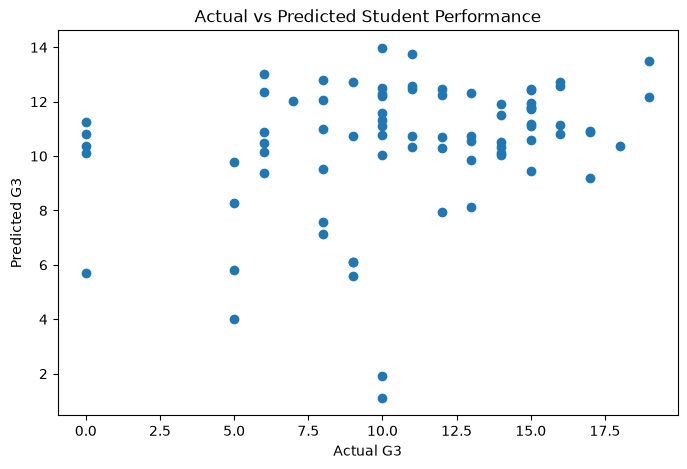

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted Student Performance")

plt.show()

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

# Make predictions
rf_pred = rf_model.predict(X_test)

# Evaluate the model
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("\nRandom Forest Evaluation")
print("------------------------")
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest model trained successfully!

Random Forest Evaluation
------------------------
MAE : 3.376075949367089
MSE : 15.811554430379742
RMSE: 3.9763745334638365
R² Score: 0.22889451442503073


In [17]:
# Compare model performance

print("Model Comparison")
print("----------------------------")
print("Linear Regression R²:", r2)
print("Random Forest R²    :", rf_r2)

print("\nLinear Regression RMSE:", rmse)
print("Random Forest RMSE    :", rf_rmse)

Model Comparison
----------------------------
Linear Regression R²: 0.00514975066116552
Random Forest R²    : 0.22889451442503073

Linear Regression RMSE: 4.51657518340391
Random Forest RMSE    : 3.9763745334638365
